In [1]:
import sys 
from pathlib import Path 
sys.path.append(str(Path().resolve().parents[0]))

import pandas as pd
import matplotlib.pyplot as plt

from config import PROCESSED_DATA_DIR

In [2]:
icustays_df = pd.read_parquet(PROCESSED_DATA_DIR / "icustays_clean.parquet")

In [3]:
def simplify_race(race):

    if pd.isna(race):
        return "UNKNOWN"

    race = race.upper()

    if "WHITE" in race:
        return "WHITE"

    elif "BLACK" in race:
        return "BLACK"

    elif "ASIAN" in race:
        return "ASIAN"

    elif "HISPANIC" in race:
        return "HISPANIC"

    elif race == "UNKNOWN":
        return "UNKNOWN"

    else:
        return "OTHER"

In [4]:
print(icustays_df.shape)
print(icustays_df.isna().sum())
print(icustays_df.duplicated(subset=["subject_id", "hadm_id", "stay_id"]).sum())

(94444, 16)
subject_id            0
hadm_id               0
stay_id               0
first_careunit        0
intime                0
outtime               0
los                   0
gender                0
anchor_age            0
admittime             0
admission_type        0
admission_location    0
insurance             0
language              0
marital_status        0
race                  0
dtype: int64
0


In [5]:
categorical_cols = [
    "first_careunit",
    "gender",
    "admission_type",
    "admission_location",
    "insurance",
    "language",
    "marital_status",
    "race"
]

for col in categorical_cols:
    print(f"Column: {col}: {icustays_df[col].nunique()}")

Column: first_careunit: 17
Column: gender: 2
Column: admission_type: 9
Column: admission_location: 11
Column: insurance: 6
Column: language: 26
Column: marital_status: 5
Column: race: 33


In [6]:
# Keep categorical variables as readable categories in this feature table.
# One-hot encoding should happen later in the final modeling/preprocessing step.
categorical_cols = [
    "gender",
    "marital_status",
    "insurance",
    "admission_type",
    "admission_location",
    "first_careunit"
]

icustays_df[categorical_cols].nunique()

gender                 2
marital_status         5
insurance              6
admission_type         9
admission_location    11
first_careunit        17
dtype: int64

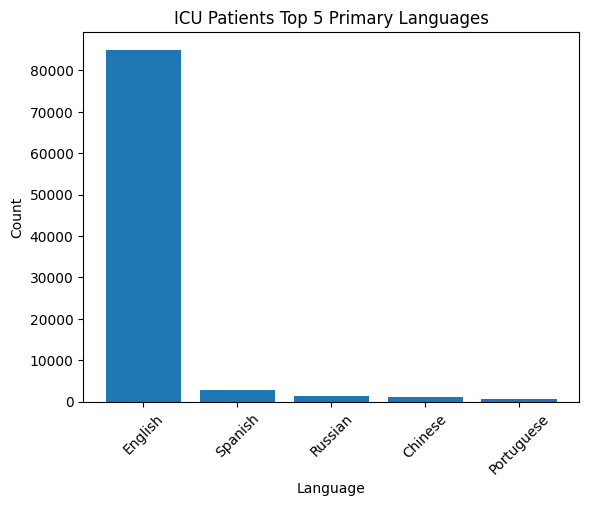

In [7]:
language_counts = icustays_df["language"].value_counts().head(5)

plt.bar(language_counts.index, language_counts.values)
plt.title("ICU Patients Top 5 Primary Languages")
plt.xlabel("Language")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

icustays_df["language_grouped"] = icustays_df["language"].where(
    icustays_df["language"].isin(language_counts.index),
    "Other"
)

icustays_df["is_english"] = (icustays_df["language"] == "English").astype(int)

icustays_df = icustays_df.drop(columns=["language"])

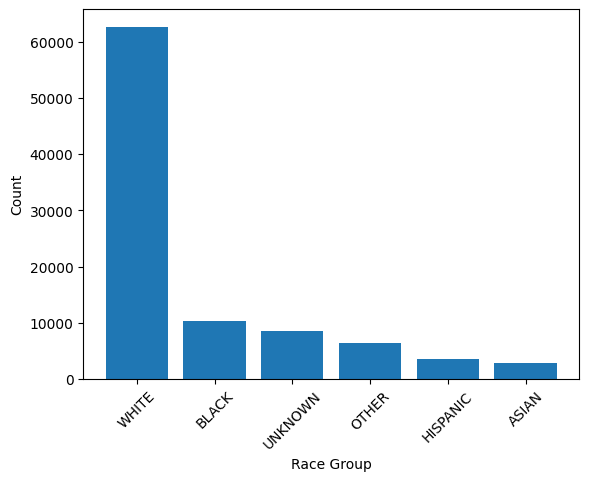

In [8]:
icustays_df["race_grouped"] = icustays_df["race"].apply(simplify_race)

race_grouped_counts = icustays_df["race_grouped"].value_counts()

plt.bar(race_grouped_counts.index, race_grouped_counts.values)
plt.xlabel("Race Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

icustays_df = icustays_df.drop(columns=["race"])

In [9]:
datetime_cols = ["intime", "outtime", "admittime"]

for col in datetime_cols:
    icustays_df[col] = pd.to_datetime(icustays_df[col])

if {"edregtime", "edouttime"}.issubset(icustays_df.columns):
    icustays_df["edregtime"] = pd.to_datetime(icustays_df["edregtime"])
    icustays_df["edouttime"] = pd.to_datetime(icustays_df["edouttime"])

In [10]:
icustays_df["icu_admit_hour"] = icustays_df["intime"].dt.hour
icustays_df["icu_admit_dayofweek"] = icustays_df["intime"].dt.dayofweek
icustays_df["icu_admit_weekend"] = icustays_df["icu_admit_dayofweek"].isin([5, 6]).astype(int)

hospital_to_icu_hours_raw = (
    (icustays_df["intime"] - icustays_df["admittime"])
    .dt.total_seconds()
    .div(3600)
)

icustays_df["icu_before_hospital_admit"] = (hospital_to_icu_hours_raw < 0).astype(int)
icustays_df["hospital_to_icu_hours"] = hospital_to_icu_hours_raw.clip(lower=0)
icustays_df["direct_icu_admit"] = hospital_to_icu_hours_raw.between(0, 6, inclusive="both").astype(int)

In [11]:
icustays_df["age_group"] = pd.cut(
    icustays_df["anchor_age"],
    bins=[0, 39, 59, 79, float("inf")],
    labels=["18-39", "40-59", "60-79", "80+"],
    right=True
)

In [12]:
def group_admission_type(admission_type):
    admission_type = admission_type.upper()

    if "ELECTIVE" in admission_type or "SURGICAL SAME DAY" in admission_type:
        return "ELECTIVE"

    elif "OBSERVATION" in admission_type:
        return "OBSERVATION"

    elif "URGENT" in admission_type:
        return "URGENT"

    elif "EMER" in admission_type:
        return "EMERGENCY"

    else:
        return "OTHER"


def group_admission_location(admission_location):
    admission_location = admission_location.upper()

    if "EMERGENCY ROOM" in admission_location:
        return "ED"

    elif "TRANSFER" in admission_location:
        return "TRANSFER"

    elif "PHYSICIAN REFERRAL" in admission_location or "CLINIC REFERRAL" in admission_location:
        return "REFERRAL"

    elif "PROCEDURE" in admission_location or "PACU" in admission_location or "SURGERY" in admission_location:
        return "PROCEDURE_OR_PACU"

    elif "WALK-IN" in admission_location:
        return "WALK_IN"

    else:
        return "OTHER"


def group_careunit(careunit):
    careunit = careunit.upper()

    if "CARDIAC" in careunit or "CORONARY" in careunit or "CVICU" in careunit or "CCU" in careunit:
        return "CARDIAC"

    elif "MEDICAL" in careunit or "MICU" in careunit:
        return "MEDICAL"

    elif "SURG" in careunit or "SICU" in careunit:
        return "SURGICAL"

    elif "NEURO" in careunit:
        return "NEURO"

    elif "TRAUMA" in careunit:
        return "TRAUMA"

    else:
        return "OTHER"

In [13]:
icustays_df["admission_urgency_group"] = icustays_df["admission_type"].apply(group_admission_type)
icustays_df["admission_source_group"] = icustays_df["admission_location"].apply(group_admission_location)
icustays_df["careunit_group"] = icustays_df["first_careunit"].apply(group_careunit)

icustays_df[
    [
        "admission_urgency_group",
        "admission_source_group",
        "careunit_group"
    ]
].nunique()

admission_urgency_group    4
admission_source_group     6
careunit_group             5
dtype: int64

In [14]:
if {"edregtime", "edouttime"}.issubset(icustays_df.columns):
    icustays_df["has_ed_stay"] = icustays_df["edregtime"].notna().astype(int)
    icustays_df["ed_los_hours"] = (
        (icustays_df["edouttime"] - icustays_df["edregtime"])
        .dt.total_seconds()
        .div(3600)
    )
    icustays_df["ed_to_icu_hours"] = (
        (icustays_df["intime"] - icustays_df["edouttime"])
        .dt.total_seconds()
        .div(3600)
    )
else:
    print("ED timestamp columns are not available in icustays_clean.parquet; skipping ED-derived features.")

ED timestamp columns are not available in icustays_clean.parquet; skipping ED-derived features.


In [15]:
engineered_cols = [
    "language_grouped",
    "is_english",
    "race_grouped",
    "icu_admit_hour",
    "icu_admit_dayofweek",
    "icu_admit_weekend",
    "icu_before_hospital_admit",
    "hospital_to_icu_hours",
    "direct_icu_admit",
    "age_group",
    "admission_urgency_group",
    "admission_source_group",
    "careunit_group"
]

ed_engineered_cols = ["has_ed_stay", "ed_los_hours", "ed_to_icu_hours"]
engineered_cols += [col for col in ed_engineered_cols if col in icustays_df.columns]

print(f"Engineered feature count: {len(engineered_cols)}")
print(engineered_cols)
print(icustays_df[engineered_cols].isna().sum())

Engineered feature count: 13
['language_grouped', 'is_english', 'race_grouped', 'icu_admit_hour', 'icu_admit_dayofweek', 'icu_admit_weekend', 'icu_before_hospital_admit', 'hospital_to_icu_hours', 'direct_icu_admit', 'age_group', 'admission_urgency_group', 'admission_source_group', 'careunit_group']
language_grouped             0
is_english                   0
race_grouped                 0
icu_admit_hour               0
icu_admit_dayofweek          0
icu_admit_weekend            0
icu_before_hospital_admit    0
hospital_to_icu_hours        0
direct_icu_admit             0
age_group                    0
admission_urgency_group      0
admission_source_group       0
careunit_group               0
dtype: int64


In [16]:
icustays_df.to_parquet(
    PROCESSED_DATA_DIR / "icustays_features.parquet",
    index=False
)